# 01 - Exploratory Data Analysis (EDA)
Analyze Spotify chart data: genre distribution, total streams, and yearly trends.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load dataset
df = pd.read_csv('../data/spotify_final_cleaned.csv')

# Preview dataset
print(df.head())

# Dataset info
print(df.info())

   Position                                Track Name          Artist  Genre  \
0         1                                 La Diabla            Xavi  Latin   
1       128                                  Amargura         Karol G  Latin   
2       129  Why'D You Only Call Me When You'Re High?  Arctic Monkeys   Rock   
3       130                             Perfect Night     Le Sserafim  K-Pop   
4       131                                  Cardigan    Taylor Swift    Pop   

    Streams        Date  Year  Month  Weeks on Chart  
0  39499314  2024-01-25  2024      1               7  
1   9834351  2024-01-25  2024      1              36  
2   9779524  2024-01-25  2024      1             111  
3   9770065  2024-01-25  2024      1              13  
4   9759708  2024-01-25  2024      1              57  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5800 entries, 0 to 5799
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  --

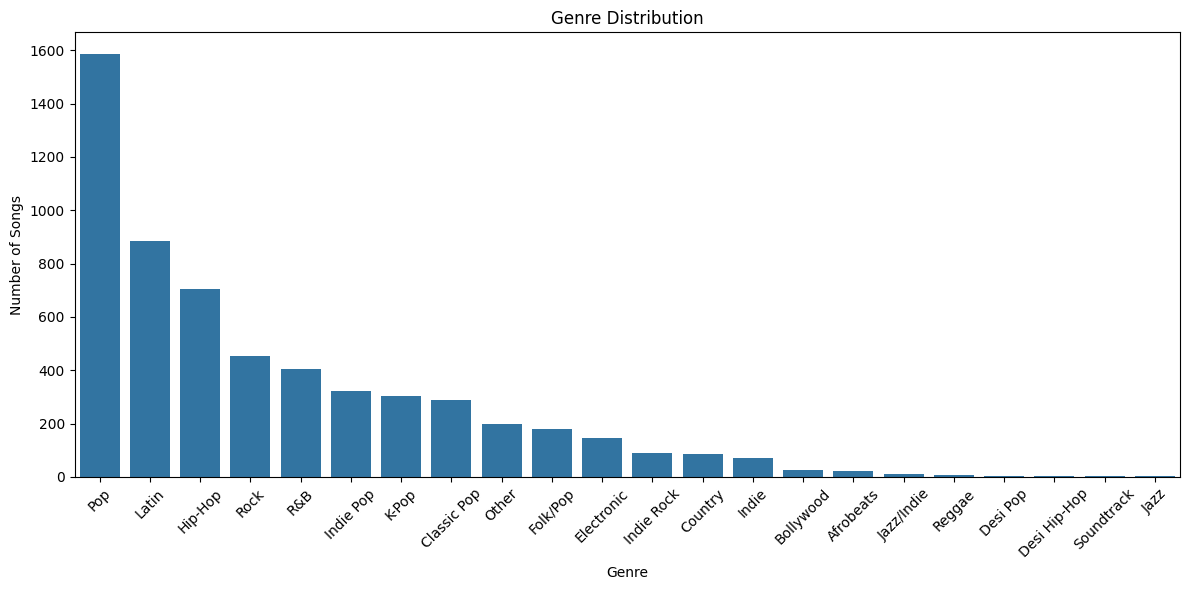

In [3]:
# Genre distribution
genre_count = df['Genre'].value_counts()

plt.figure(figsize=(12,6))

sns.barplot(
    x=genre_count.index,
    y=genre_count.values
)

plt.xticks(rotation=45)

plt.title('Genre Distribution')
plt.xlabel('Genre')
plt.ylabel('Number of Songs')

plt.tight_layout()
plt.show()

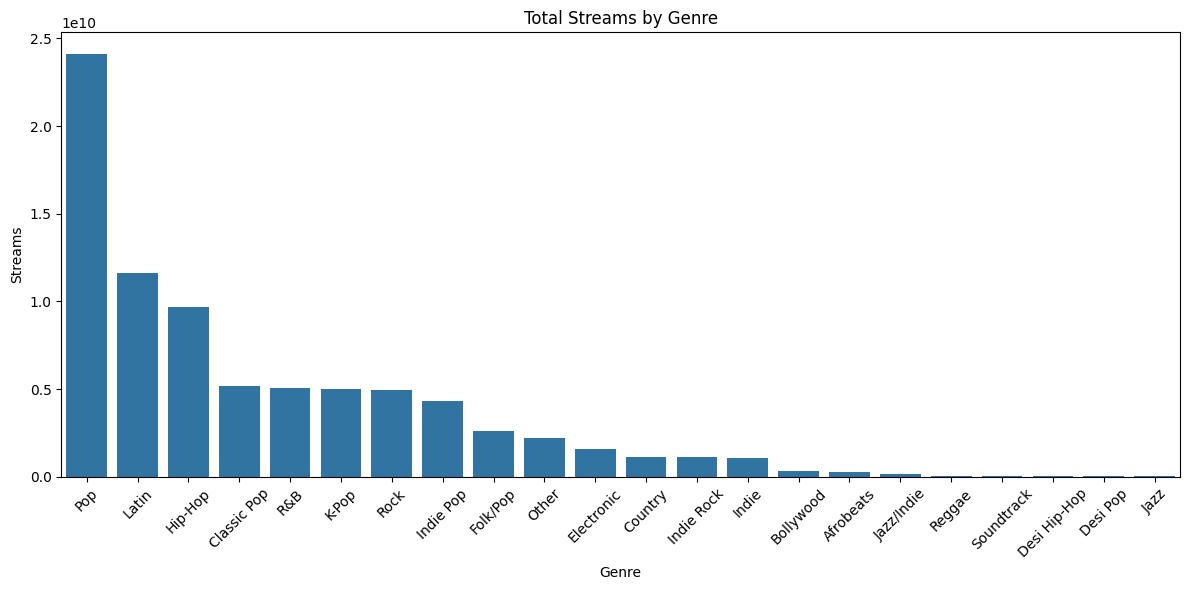

In [4]:
# Total streams by genre
genre_streams = (
    df.groupby('Genre')['Streams']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=genre_streams.index,
    y=genre_streams.values
)

plt.xticks(rotation=45)

plt.title('Total Streams by Genre')
plt.xlabel('Genre')
plt.ylabel('Streams')

plt.tight_layout()
plt.show()

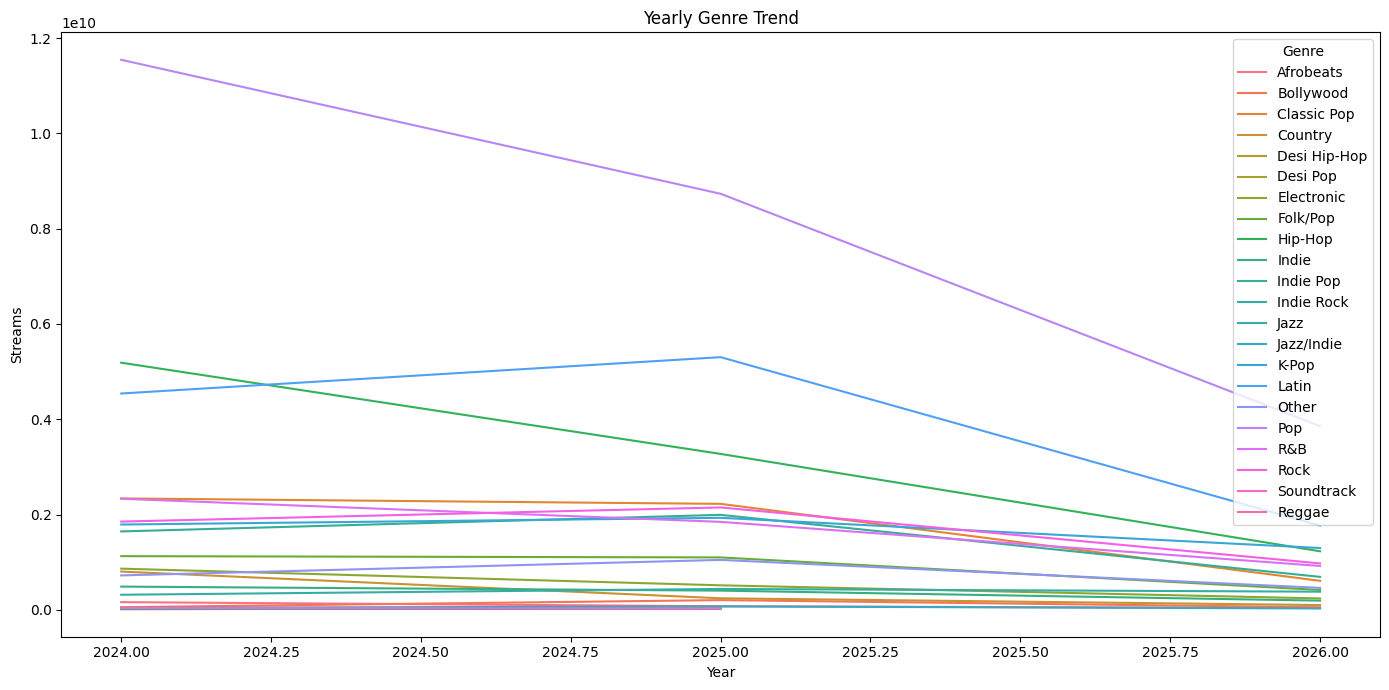

In [5]:
# Yearly trend
yearly_trend = (
    df.groupby(['Year', 'Genre'])['Streams']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,7))

sns.lineplot(
    data=yearly_trend,
    x='Year',
    y='Streams',
    hue='Genre'
)

plt.title('Yearly Genre Trend')
plt.xlabel('Year')
plt.ylabel('Streams')

plt.tight_layout()
plt.show()